# **Business Understanding**

This project is to identify, measure, and quantify the influence of modifiable lifestyle factors on an individual's Cognitive Performance.

**Business Goal:**
The organization like corporate wellness provider or digital health app aims to accurately determine the optimal lifestyle profile required to maximize an individual's Cognitive_Score.

**This goal strategically balances two outcomes:** ensuring peak mental performance (focus, learning, decision-making) for improved productivity and proactively managing long-term mental health risks by recommending personalized interventions.

**Significance of the Target Variable:**
The Cognitive_Score is the direct measure of mental output and efficiency. Inaccurate assessment of cognitive drivers poses a major risk: ignoring factors that are high influencers (like Stress_Level) leads to ineffective wellness programs, while neglecting potential issues sacrifices future productivity. Therefore, predicting this score is a crucial Key Performance Indicator (KPI) for evaluating health program Return on Investment (ROI) and early risk detection.

**Value Proposition:**
By implementing a predictive model, the business can shift from relying on generic health advice to instant, data-driven performance guidance. This allows managers and users to:

**Focus Interventions:** Quantify the impact of each factor

**Personalize Recommendations:**
Provide users with evidence-based, personalized advice that directly addresses their specific cognitive profile.

**Optimize Resource Allocation:** Identify which operational or lifestyle variables (Diet_Type, Exercise_Frequency) are the most efficient levers for improving overall employee/user mental performance.

# **Problem Statement**
Measuring and Optimizing the Impact of Lifestyle on Cognitive Performance

How can we construct an interpretable and reliable Regression model to predict an individual's Cognitive_Score, and more importantly, identify and quantify the weighted influence of each lifestyle factor (Sleep_Duration, Stress_Level, Caffeine_Intake, etc.) on individual cognitive outcomes, thereby enabling wellness programs to design the most effective interventions?

**Analytical Goal**

The objective is to utilize Regression models (such as Random Forest or XGBoost) to map the non-linear relationships between daily habits and brain performance. The goal is two-fold: to minimize the prediction error (RMSE) while maximizing the interpretability of Feature Importance for the lifestyle factors

# **Import Library**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# **Load Data**

In [ ]:
df = pd.read_csv("cognitive_performance1.csv")

In [ ]:
df.head()

,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score
0,U1,57,Female,6.5,3.0,Non-Vegetarian,6.5,Medium,41,583.33,65.0,36.71
1,U2,39,Female,NaN,9.0,Non-Vegetarian,10.8,High,214,368.24,58.0,54.35
2,U3,26,Male,8.2,6.0,Vegetarian,5.7,Low,429,445.21,49.0,32.57
3,U4,32,Male,7.8,9.0,Vegetarian,8.3,Low,464,286.33,94.0,70.15
4,U5,50,Male,9.7,2.0,Non-Vegetarian,11.3,Medium,365,237.65,62.0,87.54


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84000 entries, 0 to 83999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             84000 non-null  object 
 1   Age                 84000 non-null  int64  
 2   Gender              84000 non-null  object 
 3   Sleep_Duration      79800 non-null  float64
 4   Stress_Level        79800 non-null  float64
 5   Diet_Type           84000 non-null  object 
 6   Daily_Screen_Time   84000 non-null  float64
 7   Exercise_Frequency  84000 non-null  object 
 8   Caffeine_Intake     84000 non-null  int64  
 9   Reaction_Time       84000 non-null  float64
 10  Memory_Test_Score   79800 non-null  float64
 11  Cognitive_Score     84000 non-null  float64
dtypes: float64(6), int64(2), object(4)
memory usage: 7.7+ MB


In [ ]:
df.duplicated().sum()

np.int64(2995)

In [ ]:
for col in df.columns:
    print(col)
    print(df[col].isnull().sum())

User_ID
0
Age
0
Gender
0
Sleep_Duration
4200
Stress_Level
4200
Diet_Type
0
Daily_Screen_Time
0
Exercise_Frequency
0
Caffeine_Intake
0
Reaction_Time
0
Memory_Test_Score
4200
Cognitive_Score
0


In [ ]:
# initialization x and y
x = df.drop('Cognitive_Score', axis=1)
y = df['Cognitive_Score']

# **Exploratory Data Analysis**

In [ ]:
x.shape

(84000, 11)

In [ ]:
for col in x.columns:
    print(col)
    print(x[col].isnull().sum())

User_ID
0
Age
0
Gender
0
Sleep_Duration
4200
Stress_Level
4200
Diet_Type
0
Daily_Screen_Time
0
Exercise_Frequency
0
Caffeine_Intake
0
Reaction_Time
0
Memory_Test_Score
4200


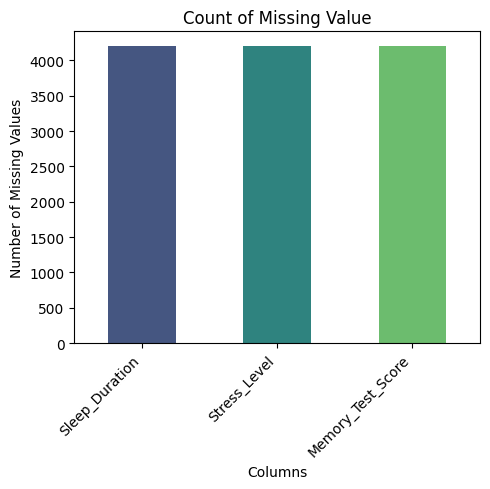

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]

if not missing_data.empty:
    plt.figure(figsize=(5, 5))
    sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis', width=0.5)
    plt.title('Count of Missing Value')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the DataFrame.")

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84000 entries, 0 to 83999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             84000 non-null  object 
 1   Age                 84000 non-null  int64  
 2   Gender              84000 non-null  object 
 3   Sleep_Duration      79800 non-null  float64
 4   Stress_Level        79800 non-null  float64
 5   Diet_Type           84000 non-null  object 
 6   Daily_Screen_Time   84000 non-null  float64
 7   Exercise_Frequency  84000 non-null  object 
 8   Caffeine_Intake     84000 non-null  int64  
 9   Reaction_Time       84000 non-null  float64
 10  Memory_Test_Score   79800 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 7.0+ MB


Show the data has duplicate and null data  at Sleep_Duration, Stress_Level, and Memory_Test_Score Columns

## Data Cleaning

In [ ]:
## handle missing value on numerical data
median_Sleep_Duration = df['Sleep_Duration'].median()
df['Sleep_Duration'].fillna(median_Sleep_Duration, inplace=True)

median_Stress_Level = df['Stress_Level'].median()
df['Stress_Level'].fillna(median_Stress_Level, inplace=True)

median_Memory_Test_Score = df['Memory_Test_Score'].median()
df['Memory_Test_Score'].fillna(median_Memory_Test_Score, inplace=True)

In [ ]:
# delete duplicate row
df.drop_duplicates(inplace=True)

In [ ]:
print("Missing values in df after imputation:")
print(df.isnull().sum())

print("\nTotal duplicate rows in df after cleaning:")
print(df.duplicated().sum())

# Re-initialize x and y
x = df.drop('Cognitive_Score', axis=1)
y = df['Cognitive_Score']


Missing values in df after imputation:
User_ID               0
Age                   0
Gender                0
Sleep_Duration        0
Stress_Level          0
Diet_Type             0
Daily_Screen_Time     0
Exercise_Frequency    0
Caffeine_Intake       0
Reaction_Time         0
Memory_Test_Score     0
Cognitive_Score       0
dtype: int64

Total duplicate rows in df after cleaning:
0


In [ ]:
# delete unnecessary columns
x.drop(['User_ID'], axis=1, inplace=True)

# **Data Understanding**

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80957 entries, 0 to 83998
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 80957 non-null  int64  
 1   Gender              80957 non-null  object 
 2   Sleep_Duration      80957 non-null  float64
 3   Stress_Level        80957 non-null  float64
 4   Diet_Type           80957 non-null  object 
 5   Daily_Screen_Time   80957 non-null  float64
 6   Exercise_Frequency  80957 non-null  object 
 7   Caffeine_Intake     80957 non-null  int64  
 8   Reaction_Time       80957 non-null  float64
 9   Memory_Test_Score   80957 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 6.8+ MB


In [ ]:
x.head()

,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score
0,57,Female,6.5,3.0,Non-Vegetarian,6.5,Medium,41,583.33,65.0
1,39,Female,7.0,9.0,Non-Vegetarian,10.8,High,214,368.24,58.0
2,26,Male,8.2,6.0,Vegetarian,5.7,Low,429,445.21,49.0
3,32,Male,7.8,9.0,Vegetarian,8.3,Low,464,286.33,94.0
4,50,Male,9.7,2.0,Non-Vegetarian,11.3,Medium,365,237.65,62.0


In [ ]:
numericCol = x[['Sleep_Duration', 'Stress_Level', 'Daily_Screen_Time', 'Caffeine_Intake', 'Reaction_Time',
       'Memory_Test_Score']]
objectCol = x[['Gender', 'Diet_Type', 'Exercise_Frequency']]

In [ ]:
numericCol

,Sleep_Duration,Stress_Level,Daily_Screen_Time,Caffeine_Intake,Reaction_Time,Memory_Test_Score
0,6.5,3.0,6.5,41,583.33,65.0
1,7.0,9.0,10.8,214,368.24,58.0
2,8.2,6.0,5.7,429,445.21,49.0
3,7.8,9.0,8.3,464,286.33,94.0
4,9.7,2.0,11.3,365,237.65,62.0
...,...,...,...,...,...,...
83984,7.6,5.0,8.1,419,236.25,69.0
83987,7.0,7.0,11.2,0,491.51,67.0
83988,4.5,9.0,3.0,387,393.79,80.0
83991,7.0,5.0,1.3,470,404.86,60.0


In [ ]:
objectCol

,Gender,Diet_Type,Exercise_Frequency
0,Female,Non-Vegetarian,Medium
1,Female,Non-Vegetarian,High
2,Male,Vegetarian,Low
3,Male,Vegetarian,Low
4,Male,Non-Vegetarian,Medium
...,...,...,...
83984,Male,Non-Vegetarian,Medium
83987,Male,Non-Vegetarian,High
83988,Male,Non-Vegetarian,Low
83991,Male,Non-Vegetarian,High


# **Univariate Analysis**

## Numeric Columns

In [ ]:
numericCol.describe()

,Sleep_Duration,Stress_Level,Daily_Screen_Time,Caffeine_Intake,Reaction_Time,Memory_Test_Score
count,80957.000000,80957.000000,80957.000000,80957.000000,80957.000000,80957.000000
mean,7.005332,5.470003,6.504239,249.013279,399.963675,69.464284
std,1.688167,2.792754,3.166694,144.513218,115.363193,16.847768
min,4.000000,1.000000,1.000000,0.000000,200.000000,40.000000
25%,5.600000,3.000000,3.800000,123.000000,300.150000,55.000000
50%,7.000000,5.000000,6.500000,249.000000,400.330000,69.000000
75%,8.400000,8.000000,9.200000,375.000000,499.190000,84.000000
max,10.000000,10.000000,12.000000,499.000000,599.990000,99.000000


In [ ]:
from scipy.stats import normaltest

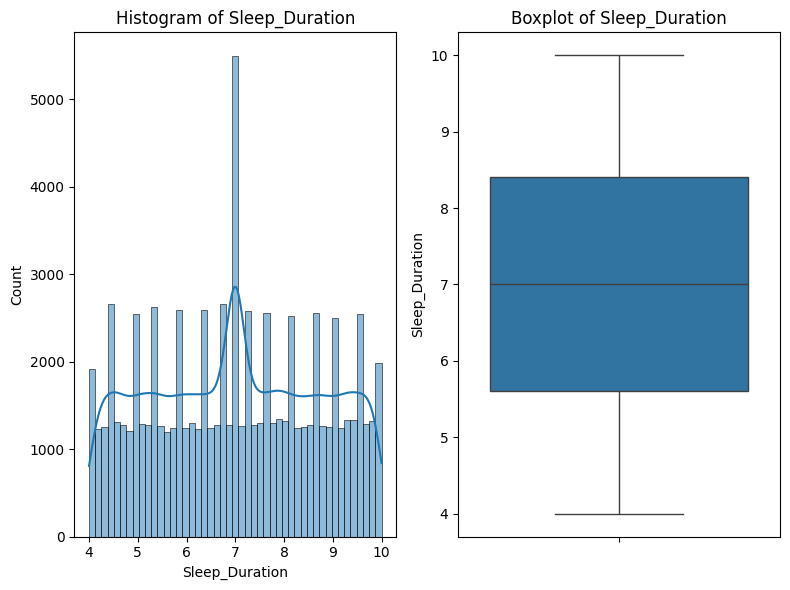

Columns : Sleep_Duration
Skewness : -0.0010529106397044964
Kurtosis : -1.0972481308062099
p - value : 0.0
The distribution is not normal


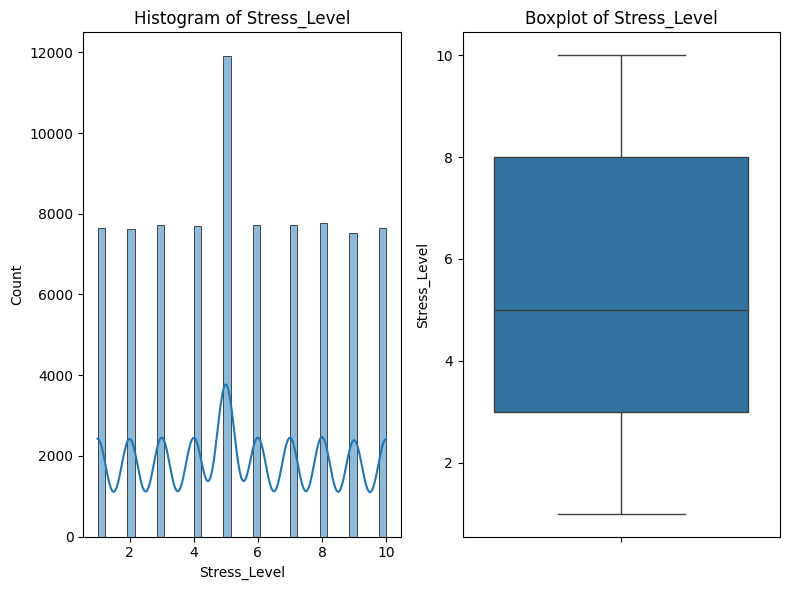

Columns : Stress_Level
Skewness : 0.028886881751777452
Kurtosis : -1.1261234092152974
p - value : 0.0
The distribution is not normal


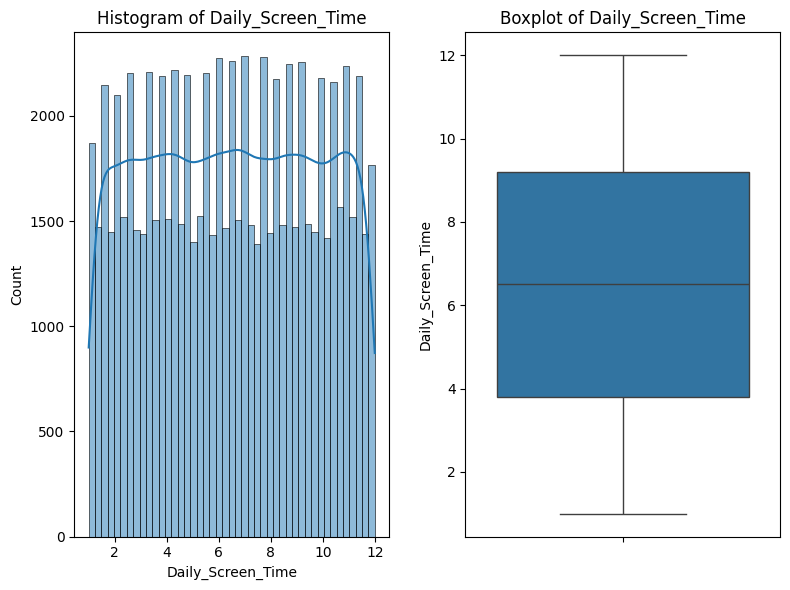

Columns : Daily_Screen_Time
Skewness : -0.0027870179265732675
Kurtosis : -1.1938615417949956
p - value : 0.0
The distribution is not normal


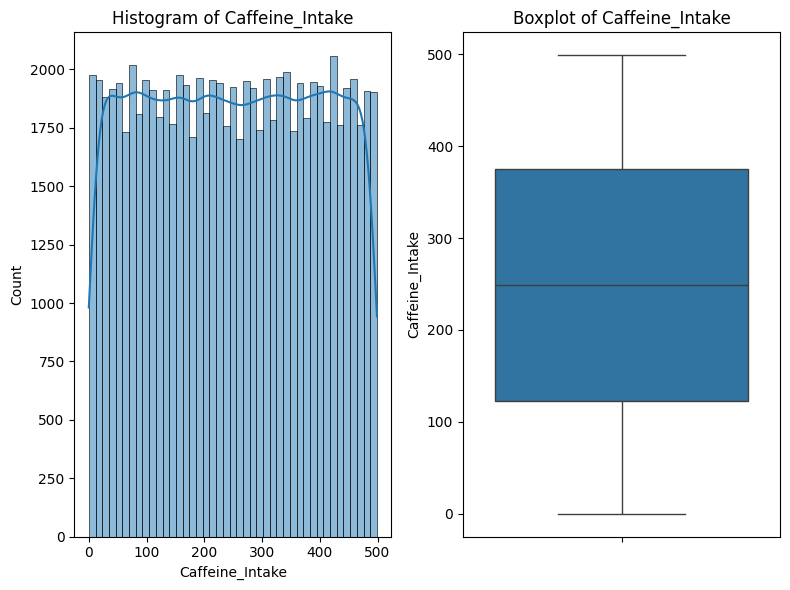

Columns : Caffeine_Intake
Skewness : -0.0001094567121230932
Kurtosis : -1.2052663344602015
p - value : 0.0
The distribution is not normal


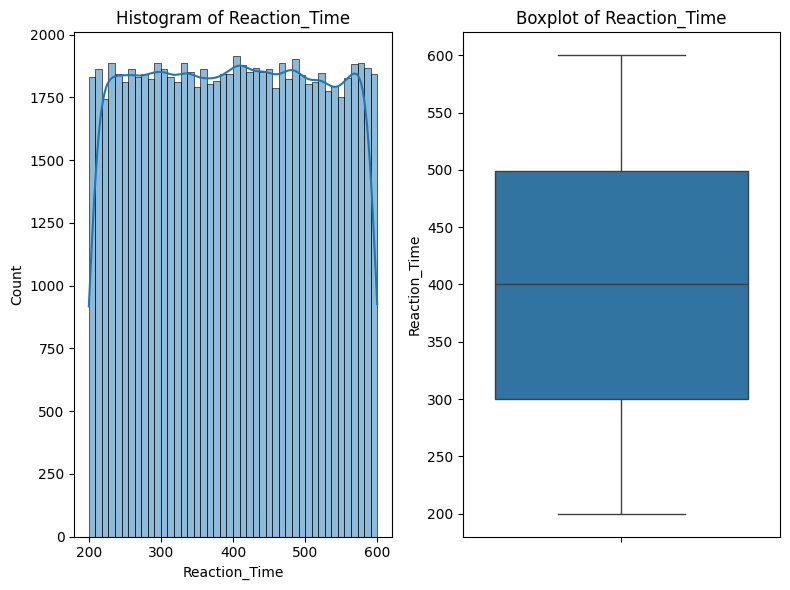

Columns : Reaction_Time
Skewness : 0.002286135970205312
Kurtosis : -1.1949572228705607
p - value : 0.0
The distribution is not normal


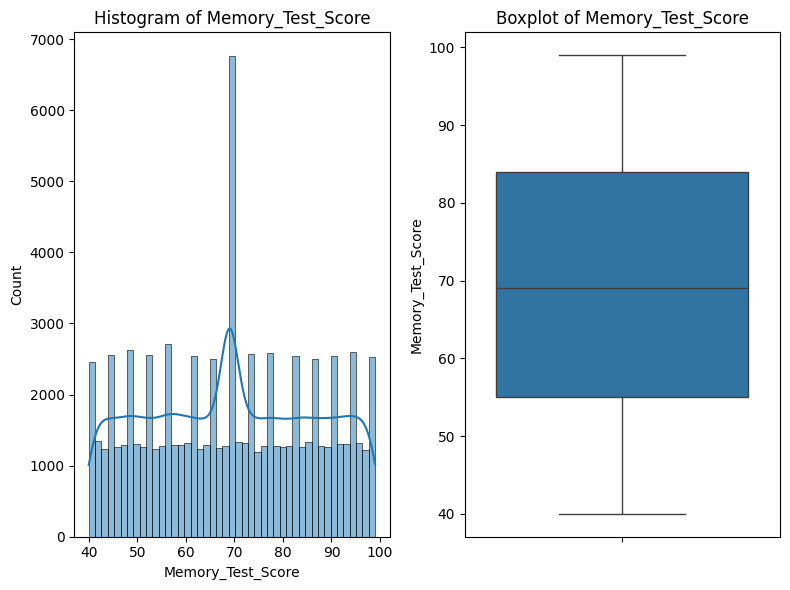

Columns : Memory_Test_Score
Skewness : 0.008819130902030469
Kurtosis : -1.1038549708731857
p - value : 0.0
The distribution is not normal


In [ ]:
for col in numericCol.columns:
    plt.figure(figsize=(8, 6))

    #histogram
    plt.subplot(1, 2, 1)
    sns.histplot(numericCol[col], kde=True)
    plt.title(f'Histogram of {col}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(y = numericCol[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

    print(f'Columns : {col}')
    print(f'Skewness : {numericCol[col].skew()}')
    print(f'Kurtosis : {numericCol[col].kurtosis()}')

    stat, p = normaltest(numericCol[col])
    print(f'p - value : {p}')
    if np.isnan(p):
      continue
    elif p > 0.05:
      print('The distribution is normal')
    else:
      print('The distribution is not normal')

In [ ]:
results = []

for col in numericCol.columns:

    skewness = numericCol[col].skew()
    kurtosis = numericCol[col].kurtosis()
    stat, p = normaltest(numericCol[col])

    if np.isnan(p):
        normality = "Unknown"
    elif p > 0.05:
        normality = "Normal"
    else:
        normality = "Not Normal"

    results.append({
        'Feature': col,
        'Normality': normality,
        'P-Value': p,
        'Skewness': skewness,
        'Kurtosis': kurtosis
    })

results_df = pd.DataFrame(results)

results_df

,Feature,Normality,P-Value,Skewness,Kurtosis
0,Sleep_Duration,Not Normal,0.0,-0.001053,-1.097248
1,Stress_Level,Not Normal,0.0,0.028887,-1.126123
2,Daily_Screen_Time,Not Normal,0.0,-0.002787,-1.193862
3,Caffeine_Intake,Not Normal,0.0,-0.000109,-1.205266
4,Reaction_Time,Not Normal,0.0,0.002286,-1.194957
5,Memory_Test_Score,Not Normal,0.0,0.008819,-1.103855


All of  numerical features are not normally distributed because the P-Value for all columns is 0.0. The data distribution is relatively symmetrical

In [ ]:
# Outlier detection each numeric column
outlier = []

for col in numericCol.columns:

    q1 = numericCol[col].quantile(0.25)
    q3 = numericCol[col].quantile(0.75)
    iqr = q3 - q1

    lower_outlier = q1 - 1.5 * iqr
    upper_outlier = q3 + 1.5 * iqr

    outliers = numericCol[(numericCol[col] < lower_outlier) | (numericCol[col] > upper_outlier)][col]

    outlier.append({
        'Column': col,
        'Outliers': len(outliers),
        'percentage_outlier' : round((len(outliers) / len(x[col])), 4) * 100
    })

outlier = pd.DataFrame(outlier)
outlier = outlier.sort_values(by='Outliers', ascending = False).reset_index(drop = True)

outlier

,Column,Outliers,percentage_outlier
0,Sleep_Duration,0,0.0
1,Stress_Level,0,0.0
2,Daily_Screen_Time,0,0.0
3,Caffeine_Intake,0,0.0
4,Reaction_Time,0,0.0
5,Memory_Test_Score,0,0.0


All of the main numerical features tested do not contain outliers.

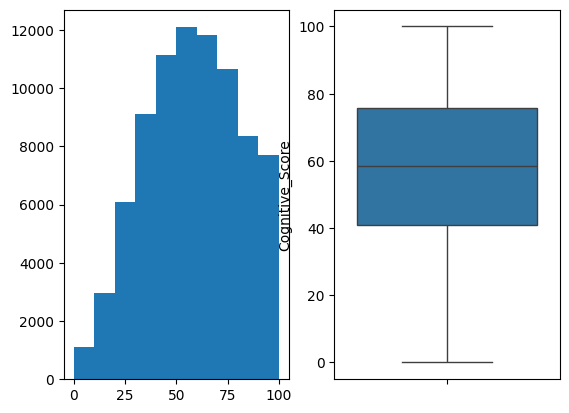

In [ ]:
# Target (Y) Variable Distribution
plt.subplot(1, 2, 1)
plt.hist(y)

plt.subplot(1, 2, 2)
sns.boxplot(y)
plt.show()

## Object Columns

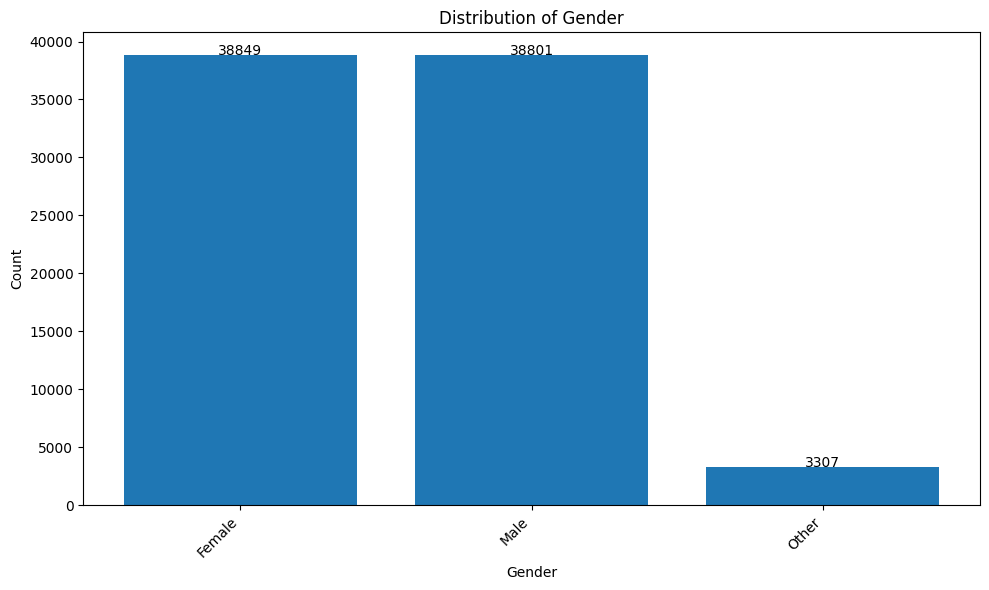

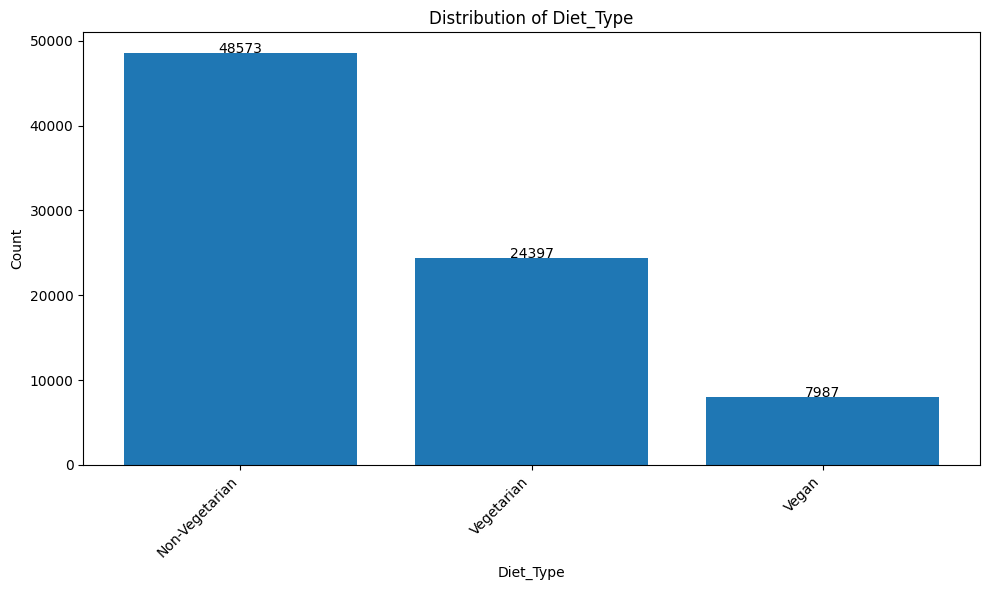

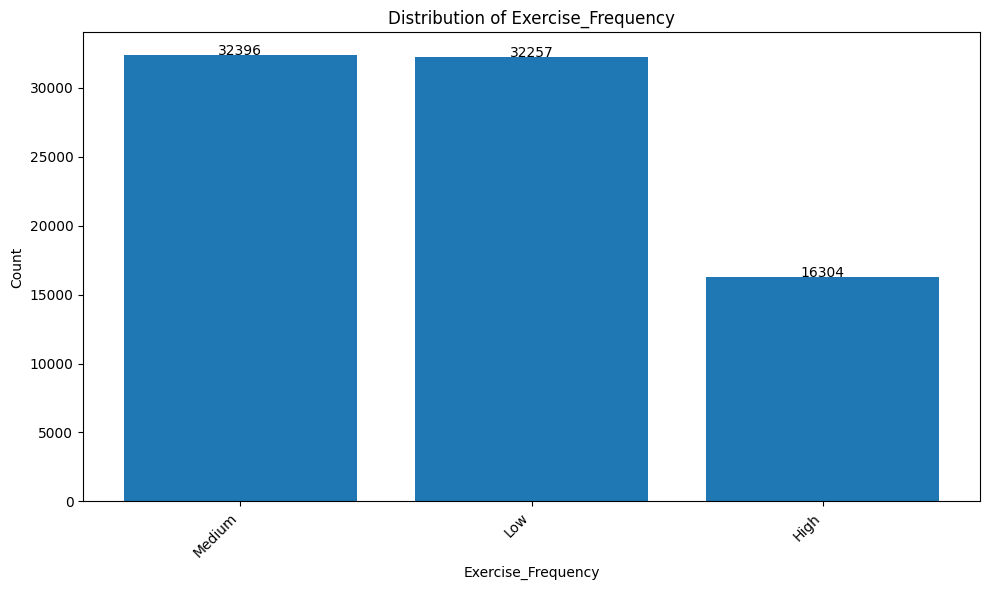

In [ ]:
for col in objectCol.columns:
  category_counts = objectCol[col].value_counts()
  plt.figure(figsize=(10, 6))

  if len(category_counts) > 15:

    top_15 = category_counts.head(15)
    plt.bar(top_15.index, top_15.values)


    for i, value in enumerate(top_15.values):
      plt.text(i, value + 1, str(value), ha = 'center', fontsize = 10)
  else:

    plt.bar(category_counts.index, category_counts.values)


    for i, value in enumerate(category_counts.values):
            plt.text(i, value + 1, str(value), ha ='center', fontsize = 10)

  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.xticks(rotation=45, ha='right', fontsize=10)
  plt.tight_layout()
  plt.show()

## Bivariate Analysis

In [ ]:
from scipy.stats import spearmanr

corr = []

for col in numericCol.columns:

    corr_coeff, p_value = spearmanr(numericCol[col], y)

    if p_value < 0.05:
        print(f"There is a statistically significant correlation between {col} and predicted_cc")
        relation = 'Correlate'
    else:
        relation = 'Not'


    corr.append({
        'Feature': col,
        'Correlation Score': corr_coeff,
        'p-value': p_value,
        'Relation': relation
    })

df_corr = pd.DataFrame(corr)

df_corr

There is a statistically significant correlation between Sleep_Duration and predicted_cc
There is a statistically significant correlation between Stress_Level and predicted_cc
There is a statistically significant correlation between Daily_Screen_Time and predicted_cc
There is a statistically significant correlation between Caffeine_Intake and predicted_cc
There is a statistically significant correlation between Reaction_Time and predicted_cc
There is a statistically significant correlation between Memory_Test_Score and predicted_cc


,Feature,Correlation Score,p-value,Relation
0,Sleep_Duration,0.139381,0.000000e+00,Correlate
1,Stress_Level,-0.211913,0.000000e+00,Correlate
2,Daily_Screen_Time,-0.189782,0.000000e+00,Correlate
3,Caffeine_Intake,-0.117108,4.210924e-245,Correlate
4,Reaction_Time,-0.824684,0.000000e+00,Correlate
5,Memory_Test_Score,0.341717,0.000000e+00,Correlate


In [ ]:

from scipy.stats import f_oneway

anova_results = []
alpha = 0.05

for col in objectCol.columns:
    categories = objectCol[col].unique()

    data_groups = [y[df[col] == category].dropna() for category in categories]


    f_stat, p_value = f_oneway(*data_groups)

    if p_value < alpha:
        relation = 'Correlate (Significant)'
    else:
        relation = 'Not Correlate (Not Significant)'

    anova_results.append({
        'Feature': col,
        'Test Type': 'ANOVA (F-test)',
        'F-Statistic': f_stat,
        'p-value': p_value,
        'Relation': relation
    })

df_anova = pd.DataFrame(anova_results)

print(df_anova)

              Feature       Test Type  F-Statistic   p-value  \
0              Gender  ANOVA (F-test)     0.293898  0.745354   
1           Diet_Type  ANOVA (F-test)     1.129577  0.323175   
2  Exercise_Frequency  ANOVA (F-test)  2622.419772  0.000000   

                          Relation  
0  Not Correlate (Not Significant)  
1  Not Correlate (Not Significant)  
2          Correlate (Significant)  


The Gender and Diet_Type columns should be dropped because the statistical test results (P-value > 0.05) indicate they are very weak predictors (not statistically significant) for the Cognitive_Score.

In [ ]:
# drop Gender and Diet_Type Column
x.drop(['Gender', 'Diet_Type'], axis=1, inplace=True)
objectCol.drop(['Gender', 'Diet_Type'], axis=1, inplace=True)
df.drop(['Gender', 'Diet_Type'], axis=1, inplace=True)

In [ ]:
df.drop(['User_ID'], axis=1, inplace=True)

**Multivariate Analysis**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80957 entries, 0 to 83998
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 80957 non-null  int64  
 1   Sleep_Duration      80957 non-null  float64
 2   Stress_Level        80957 non-null  float64
 3   Daily_Screen_Time   80957 non-null  float64
 4   Exercise_Frequency  80957 non-null  object 
 5   Caffeine_Intake     80957 non-null  int64  
 6   Reaction_Time       80957 non-null  float64
 7   Memory_Test_Score   80957 non-null  float64
 8   Cognitive_Score     80957 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 6.2+ MB


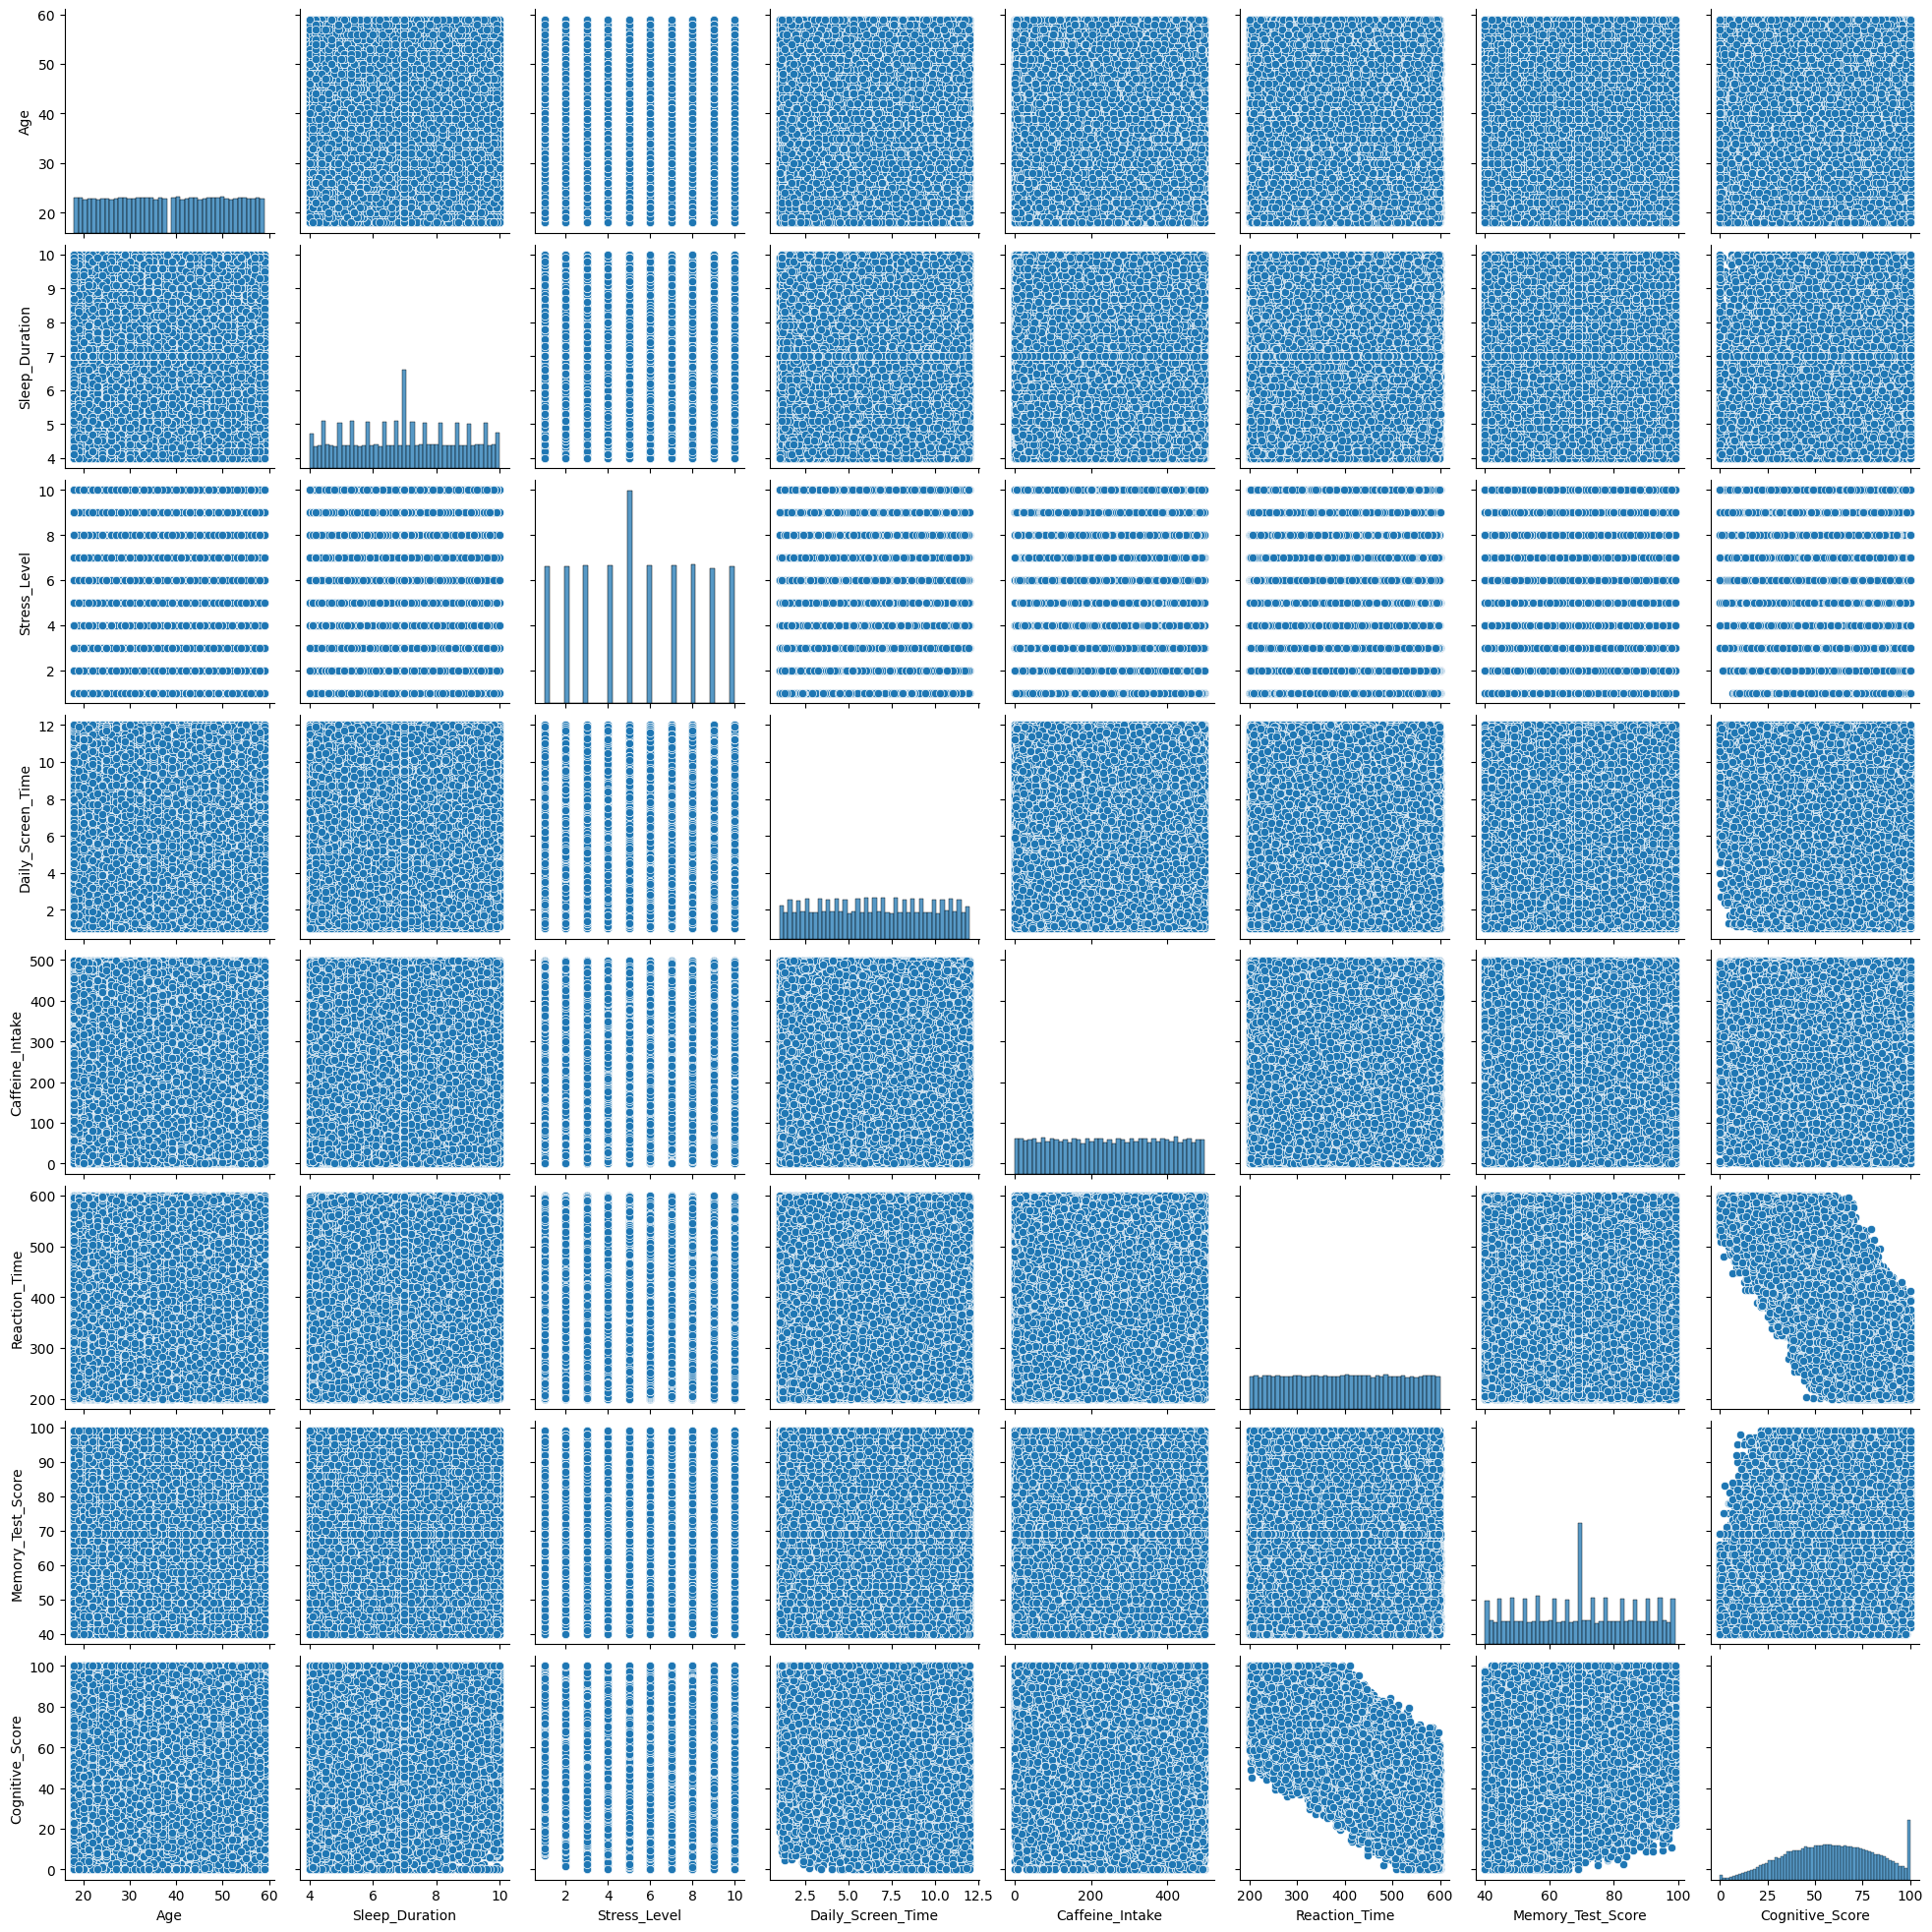

In [ ]:
sns.pairplot(df, palette = 'husl')

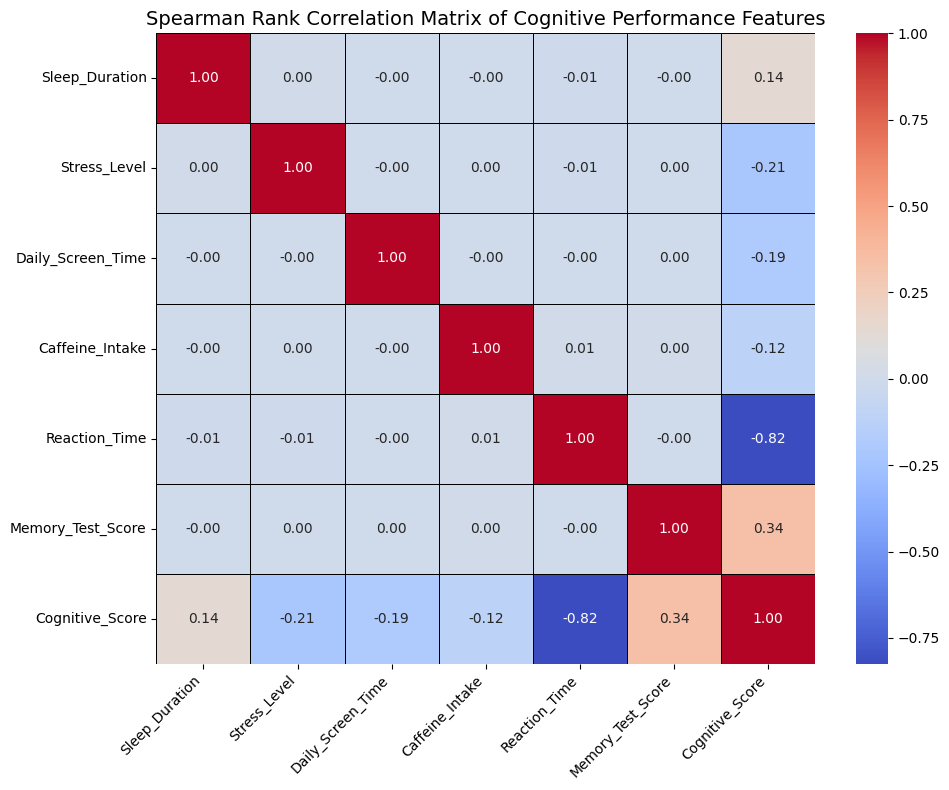

In [ ]:
all_numeric_cols = pd.concat([numericCol, y], axis=1)
corr_matrix = all_numeric_cols.corr(method='spearman')

# Heatmap for all_numeric_cols
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True, linewidths=.5, linecolor='black')
plt.title('Spearman Rank Correlation Matrix of Cognitive Performance Features', fontsize=14)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

The results decisively establish that Reaction Time (very strong negative correlation) and Exercise Frequency (highly significant predictor) are the primary and most decisive factors of your Cognitive Score.

While Memory Test Score also shows a moderate positive correlation, other variables—including Stress Level (very weak negative correlation) and Daily Screen Time—demonstrate minimal or statistically insignificant relationships.

Therefore, interventions designed for the greatest impact on cognitive performance must strategically prioritize improving mental processing speed (reducing Reaction Time) and enhancing physical activity (Exercise Frequency)

# **Feature Engineering**

In [ ]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()

for col in objectCol.columns:
    objectCol[col] = enc.fit_transform(objectCol[col])

objectCol.head()


,Exercise_Frequency
0,2
1,0
2,1
3,1
4,2


In [ ]:
# merging
data = pd.merge(numericCol, objectCol, how = 'outer', left_index = True, right_index = True)
data.isnull().sum()


,0
Sleep_Duration,0
Stress_Level,0
Daily_Screen_Time,0
Caffeine_Intake,0
Reaction_Time,0
Memory_Test_Score,0
Exercise_Frequency,0


In [ ]:
data.head()

,Sleep_Duration,Stress_Level,Daily_Screen_Time,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Exercise_Frequency
0,6.5,3.0,6.5,41,583.33,65.0,2
1,7.0,9.0,10.8,214,368.24,58.0,0
2,8.2,6.0,5.7,429,445.21,49.0,1
3,7.8,9.0,8.3,464,286.33,94.0,1
4,9.7,2.0,11.3,365,237.65,62.0,2


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80957 entries, 0 to 83998
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Sleep_Duration      80957 non-null  float64
 1   Stress_Level        80957 non-null  float64
 2   Daily_Screen_Time   80957 non-null  float64
 3   Caffeine_Intake     80957 non-null  int64  
 4   Reaction_Time       80957 non-null  float64
 5   Memory_Test_Score   80957 non-null  float64
 6   Exercise_Frequency  80957 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 4.9 MB


In [ ]:
# Normalization
from sklearn.preprocessing import RobustScaler

scale = RobustScaler()

data_norm = pd.DataFrame(scale.fit_transform(data), columns = data.columns)

data_norm.head()

,Sleep_Duration,Stress_Level,Daily_Screen_Time,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Exercise_Frequency
0,-0.178571,-0.4,0.000000,-0.825397,0.919413,-0.137931,1.0
1,0.000000,0.8,0.796296,-0.138889,-0.161224,-0.379310,-1.0
2,0.428571,0.2,-0.148148,0.714286,0.225482,-0.689655,0.0
3,0.285714,0.8,0.333333,0.853175,-0.572749,0.862069,0.0
4,0.964286,-0.6,0.888889,0.460317,-0.817323,-0.241379,1.0


In [ ]:
# Spliting Data
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(data_norm, y, test_size = 0.2, random_state = 0)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(64765, 7)
(16192, 7)
(64765,)
(16192,)


In [ ]:
# import library for regressormodel
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Ensemble Learning
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error as MSE, mean_absolute_error as MAE, r2_score

# **Modelling**

In [ ]:
dt = DecisionTreeRegressor()
ln = LinearRegression()
rf = RandomForestRegressor()
xg = XGBRegressor(objective = 'reg:squarederror', random_state = 0)

dt.fit(x_train, y_train)
ln.fit(x_train, y_train)
rf.fit(x_train, y_train)
xg.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)
y_pred_ln = ln.predict(x_test)
y_pred_rf = rf.predict(x_test)
y_pred_xg = xg.predict(x_test)

metrics = {
    "Model": ["Decision Tree", "Linear Regression", "Random Forest", "XGBRegressor"],
    "R2_Score": [
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_ln),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xg),
    ],
    "MAE": [
        MAE(y_test, y_pred_dt),
        MAE(y_test, y_pred_ln),
        MAE(y_test, y_pred_rf),
        MAE(y_test, y_pred_xg),
    ],
    "MSE": [
        MSE(y_test, y_pred_dt),
        MSE(y_test, y_pred_ln),
        MSE(y_test, y_pred_rf),
        MSE(y_test, y_pred_xg),
    ],
}

results_df = pd.DataFrame(metrics)

results_df

,Model,R2_Score,MAE,MSE
0,Decision Tree,0.937688,4.327529,33.120601
1,Linear Regression,0.921949,5.867465,41.486481
2,Random Forest,0.979292,2.337693,11.007091
3,XGBRegressor,0.983138,1.997178,8.962585


In [ ]:
# Enesamble Learning
# Voting Regressor

voting_regressor = VotingRegressor(estimators = [
    ('decision_tree', dt),
    ('linear_regression', ln),
    ('random_forest', rf),
    ('xgboost', xg)
])

voting_regressor.fit(x_train, y_train)

y_pred_voting = voting_regressor.predict(x_test)

print(f"R2 Score : {r2_score(y_test, y_pred_voting) :.5f}")
print(f"Mean Absolute Error Score : {MAE(y_test, y_pred_voting) :.5f}")
print(f"Mean Squared Error Score : {MSE(y_test, y_pred_voting) :.5f}")


R2 Score : 0.97842
Mean Absolute Error Score : 2.43854
Mean Squared Error Score : 11.47092


In [ ]:
# stacking regressor
base_models = [
    ('decision_tree', dt),
    ('linear_regression', ln),
    ('random_forest', rf),
    ('xgboost', xg)
]


In [ ]:
meta_model = Ridge(alpha = 1.0)

In [ ]:
stacking_regressor = StackingRegressor(estimators = base_models,
                                       final_estimator = meta_model,
                                       cv = 5)


In [ ]:
stacking_regressor.fit(x_train, y_train)

StackingRegressor(cv=5,
                  estimators=[('decision_tree', DecisionTreeRegressor()),
                              ('linear_regression', LinearRegression()),
                              ('random_forest', RandomForestRegressor()),
                              ('xgboost',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categoric...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                  final_estimator=Ridge())

In [ ]:
y_pred_stack = stacking_regressor.predict(x_test)

In [ ]:
print(f"R2 Score : {r2_score(y_test, y_pred_stack) :.5f}")
print(f"Mean Absolute Error Score : {MAE(y_test, y_pred_stack) :.5f}")
print(f"Mean Squared Error Score : {MSE(y_test, y_pred_stack) :.5f}")

R2 Score : 0.98509
Mean Absolute Error Score : 1.77190
Mean Squared Error Score : 7.92472


In [ ]:

y_pred_voting = voting_regressor.predict(x_test)
y_pred_stack = stacking_regressor.predict(x_test)


all_metrics = {
    "Model": [
        "Decision Tree",
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Voting Regressor",
        "Stacking Regressor"
    ],
    "R2_Score": [
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_ln),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xg),
        r2_score(y_test, y_pred_voting),
        r2_score(y_test, y_pred_stack)
    ],
    "MAE": [
        MAE(y_test, y_pred_dt),
        MAE(y_test, y_pred_ln),
        MAE(y_test, y_pred_rf),
        MAE(y_test, y_pred_xg),
        MAE(y_test, y_pred_voting),
        MAE(y_test, y_pred_stack)
    ],
    "MSE": [
        MSE(y_test, y_pred_dt),
        MSE(y_test, y_pred_ln),
        MSE(y_test, y_pred_rf),
        MSE(y_test, y_pred_xg),
        MSE(y_test, y_pred_voting),
        MSE(y_test, y_pred_stack)
    ]
}


results_all_df = pd.DataFrame(all_metrics)

results_all_df


,Model,R2_Score,MAE,MSE
0,Decision Tree,0.937695,4.327629,33.117091
1,Linear Regression,0.921949,5.867465,41.486481
2,Random Forest,0.979362,2.338326,10.969565
3,XGBoost,0.983138,1.997178,8.962585
4,Voting Regressor,0.978490,2.432128,11.433072
5,Stacking Regressor,0.985043,1.777134,7.950074


The results indicate that ensemble models perform better than single models, with XGBoost and Random Forest already showing strong predictive performance. The Stacking Regressor achieves the best results overall, having the highest R² score and the lowest error values, which suggests that combining multiple models improves accuracy and reliability.

# **Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

In [ ]:
xg_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 6, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

In [ ]:
rf = RandomForestRegressor(random_state=0)
xg = XGBRegressor(objective="reg:squarederror", random_state=0)

In [ ]:
rf_search = RandomizedSearchCV(
    rf, rf_params, n_iter=10, cv=3, random_state=0, n_jobs=-1
)

In [ ]:
xg_search = RandomizedSearchCV(
    xg, xg_params, n_iter=10, cv=3, random_state=0, n_jobs=-1
)

In [ ]:
rf_search.fit(x_train, y_train)
xg_search.fit(x_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 6, 10],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=0)

In [ ]:
best_rf = rf_search.best_estimator_
best_xg = xg_search.best_estimator_

In [ ]:
# Stacking Regressor
stacking_model = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xg)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5
)

stacking_model.fit(x_train, y_train)


StackingRegressor(cv=5,
                  estimators=[('rf',
                               RandomForestRegressor(max_depth=30,
                                                     n_estimators=300,
                                                     random_state=0)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.6, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_we...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                  final_estimator=Ridge())

In [ ]:
y_pred_rf = best_rf.predict(x_test)
y_pred_xg = best_xg.predict(x_test)
y_pred_stack = stacking_model.predict(x_test)


In [ ]:
results_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Stacking Regressor"],
    "R2_Score": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xg),
        r2_score(y_test, y_pred_stack)
    ],
    "MAE": [
        MAE(y_test, y_pred_rf),
        MAE(y_test, y_pred_xg),
        MAE(y_test, y_pred_stack)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_xg),
        mean_squared_error(y_test, y_pred_stack)
    ]
})

results_df

,Model,R2_Score,MAE,MSE
0,Random Forest,0.979737,2.307594,10.770429
1,XGBoost,0.986811,1.481643,7.010185
2,Stacking Regressor,0.987037,1.450926,6.890177


## **Model with PCA**

In [ ]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(x_train)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)


In [ ]:
n_components_best = np.argmax(cumulative_variance >= 0.95) + 1


In [ ]:
pca = PCA(n_components=n_components_best)

In [ ]:
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

In [ ]:
best_rf.fit(x_train_pca, y_train)
best_xg.fit(x_train_pca, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
stacking_pca = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xg)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5
)

In [ ]:
stacking_pca.fit(x_train_pca, y_train)

StackingRegressor(cv=5,
                  estimators=[('rf',
                               RandomForestRegressor(max_depth=30,
                                                     n_estimators=300,
                                                     random_state=0)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.6, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_we...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                  final_estimator=Ridge())

In [ ]:
y_pred_rf_pca = best_rf.predict(x_test_pca)
y_pred_xg_pca = best_xg.predict(x_test_pca)
y_pred_stack_pca = stacking_pca.predict(x_test_pca)


## **Comparison**

In [ ]:
comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest (No PCA)",
        "XGBoost (No PCA)",
        "Stacking (No PCA)",
        "Random Forest (PCA)",
        "XGBoost (PCA)",
        "Stacking (PCA)"
    ],
    "R2_Score": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xg),
        r2_score(y_test, y_pred_stack),
        r2_score(y_test, y_pred_rf_pca),
        r2_score(y_test, y_pred_xg_pca),
        r2_score(y_test, y_pred_stack_pca)
    ],
    "MAE": [
        MAE(y_test, y_pred_rf),
        MAE(y_test, y_pred_xg),
        MAE(y_test, y_pred_stack),
        MAE(y_test, y_pred_rf_pca),
        MAE(y_test, y_pred_xg_pca),
        MAE(y_test, y_pred_stack_pca)
    ],
    "MSE": [
        MSE(y_test, y_pred_rf),
        MSE(y_test, y_pred_xg),
        MSE(y_test, y_pred_stack),
        MSE(y_test, y_pred_rf_pca),
        MSE(y_test, y_pred_xg_pca),
        MSE(y_test, y_pred_stack_pca)
    ]
})

comparison_df


,Model,R2_Score,MAE,MSE
0,Random Forest (No PCA),0.979737,2.307594,10.770429
1,XGBoost (No PCA),0.986811,1.481643,7.010185
2,Stacking (No PCA),0.987037,1.450926,6.890177
3,Random Forest (PCA),0.975098,2.659506,13.236123
4,XGBoost (PCA),0.985292,1.719969,7.817997
5,Stacking (PCA),0.985553,1.688575,7.679114


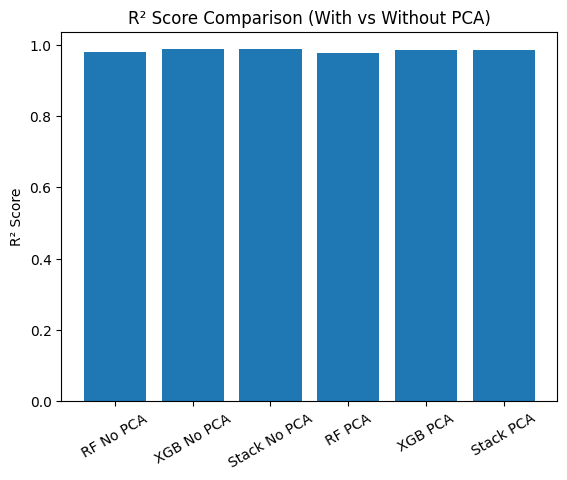

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "RF No PCA", "XGB No PCA", "Stack No PCA",
    "RF PCA", "XGB PCA", "Stack PCA"
]

r2_scores = [
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_xg),
    r2_score(y_test, y_pred_stack),
    r2_score(y_test, y_pred_rf_pca),
    r2_score(y_test, y_pred_xg_pca),
    r2_score(y_test, y_pred_stack_pca)
]

plt.figure()
plt.bar(models, r2_scores)
plt.xticks(rotation=30)
plt.ylabel("R² Score")
plt.title("R² Score Comparison (With vs Without PCA)")
plt.show()


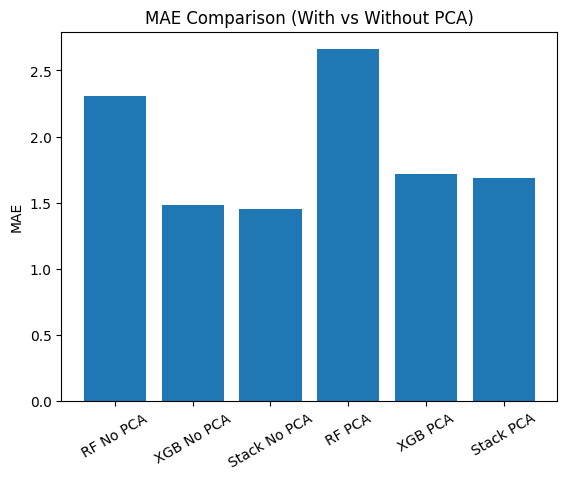

In [ ]:
mae_scores = [
    MAE(y_test, y_pred_rf),
    MAE(y_test, y_pred_xg),
    MAE(y_test, y_pred_stack),
    MAE(y_test, y_pred_rf_pca),
    MAE(y_test, y_pred_xg_pca),
    MAE(y_test, y_pred_stack_pca)
]

plt.figure()
plt.bar(models, mae_scores)
plt.xticks(rotation=30)
plt.ylabel("MAE")
plt.title("MAE Comparison (With vs Without PCA)")
plt.show()


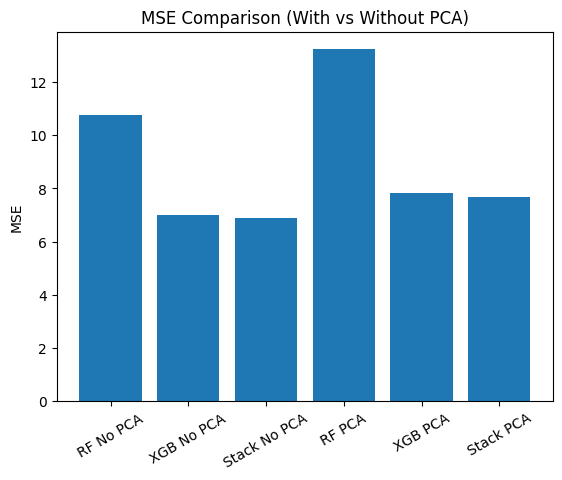

In [ ]:
mse_scores = [
    MSE(y_test, y_pred_rf),
    MSE(y_test, y_pred_xg),
    MSE(y_test, y_pred_stack),
    MSE(y_test, y_pred_rf_pca),
    MSE(y_test, y_pred_xg_pca),
    MSE(y_test, y_pred_stack_pca)
]

plt.figure()
plt.bar(models, mse_scores)
plt.xticks(rotation=30)
plt.ylabel("MSE")
plt.title("MSE Comparison (With vs Without PCA)")
plt.show()


# **Conclussion**


**1.** **Model Prediction Results**

The primary conclusion from the model evaluation phase is that accurate prediction of the **Cognitive_Score is achievable** without the need for data dimensionality reduction.

**Optimal Models:**
 The Ensemble Model (Stacking Regressor) and the Tuned Model (without PCA) demonstrated superior performance, achieving the highest $R^2$ Scores and the lowest error metrics (MAE/RMSE).

**PCA Impact**: The use of Principal Component Analysis (PCA) drastically reduced performance, indicating that every feature (even those with weak initial correlations) carries unique, essential information that should not be combined or discarded.

**2. Actionable Business Insights**

The analysis of feature importance and model performance provides highly specific intervention guidelines for enhancing cognitive performance:

**Management Focus (High Impact):**

The greatest impact on the Cognitive Score is driven by:
- **Reaction Time:** Reaction time shows the strongest influence on the Cognitive Score, indicating that faster response speed is closely associated with higher cognitive performance and overall mental efficiency.

- **Physical Activity:** Exercise_Frequency was the only categorical feature proven statistically significant, underscoring the critical role of physical activity in brain health.

- **Core Function:** Memory_Test_Score and Reaction_Time are tightly correlated with the final score, suggesting that interventions must also target the enhancement of processing speed and working memory.

- **Feature Filtering:** Features found to be statistically insignificant, namely Gender and Diet_Type, should be excluded from final models and intervention recommendations to maintain model parsimony and efficient resource allocation.

**The project successfully** built a data-driven predictive tool that empirically validates that **Stress, Memory, and Exercise Frequency are the primary keys to unlocking cognitive potential**, providing a clear roadmap for personalized and effective wellness programs.